### The Data Analysis Workshop
This is a book aims to Solve business problems with state-of-the-art data analysis models,
developing expert data analysis skills along the way.                                                                                                       
**by** Gururajan Govindan, Shubhangi Hora, and Konstantin Palagachev

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings


np.random.seed(111)
warnings.filterwarnings('ignore')
%matplotlib inline

# DATA PREPROCESSING
### Mapping columns
##### According to the description of the original data, provided in the Readme.txt file, we can split the columns into three main groups:
1. **temporal** features: This contains information about the time at which the record was registered. This group contains the dteday, season, yr, mnth hr, holiday, weekday, and workingday columns.
2. **Weather related features**: This contains information about the weather conditions. The weathersit, temp, atemp, hum, and windspeed columns 
are included in this group.
3. **record related features**: This contains information about the number of records for the specific hour and date. This group includes the casual, 
registered, and cnt columns.


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                          'PacktWorkshops/'\
'The-Data-Analysis-Workshop/'\
'master/Chapter01/data/hour.csv')  # Reading the Dataset.
df.head()  # printing the first 5 rows of the dataset.

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
print('the Shape is {}'.format(df.shape), '\n\n')  #  the shape of the data 
print(df.info())  # Some info about the columns in the dataset.

the Shape is (17379, 17) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


In [4]:
# How many null values in the dataset?
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
# Description of the numerical columns.
df.select_dtypes(exclude='object').describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


- The seasons column contains values from 1 to 4, which encode, respectively, **the Winter, Spring, Summer, and Fall seasons.** 
- The yr column contains the values 0 and 1 representing **2011 and 2012**,
- while the weekday column contains values from 0 to 6, with each one representing a day of the week **(0: Sunday, 1: Monday, through to 6: Saturday)**. 
- Furthermore, we scale the hum column to values between 0 and 100 (as it represents the humidity percentage),
and the windspeed column to values between 0 and 67 (as those are the registered minimum and maximum wind speed)

### For our Analysis we need to map all those columns so we can get the best of the visualization.

In [6]:
# create a copy of the original data
preprocessed_data = df.copy()

# tranform seasons
seasons_mapping = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'}
preprocessed_data['season'] = preprocessed_data['season'].map(seasons_mapping)

# transform yr
yr_mapping = {0: 2011, 1: 2012}
preprocessed_data['yr'] = preprocessed_data['yr'].map(yr_mapping)

# transform weekday
weekday_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
preprocessed_data['weekday'] = preprocessed_data['weekday'].map(weekday_mapping)

# transform weathersit
weather_mapping = {1: 'clear', 2: 'cloudy', 3: 'light_rain_snow', 4: 'heavy_rain_snow'}
preprocessed_data['weathersit'] = preprocessed_data['weathersit'].map(weather_mapping) 

# transorm hum and windspeed
preprocessed_data['hum'] = preprocessed_data['hum'] * 100
preprocessed_data['windspeed'] = preprocessed_data['windspeed'] * 67

# visualize preprocessed columns
cols = ['season', 'yr', 'weekday', 'weathersit', 'hum', 'windspeed']
preprocessed_data[cols].sample(10, random_state=123)

preprocessed_data.to_csv('new_hour.csv')

## Let's Start Our Analysis now

A validation step is to make sure that cnt column equals the registered + casual
- we will use the assert keyword to check. if they are equal then nothing will happen if not the Editor will throw an error.

In [7]:
assert (df.cnt == (df.registered + df.casual)).all()

- first of all let's see the distribution  of the Registered and the Casual columns.

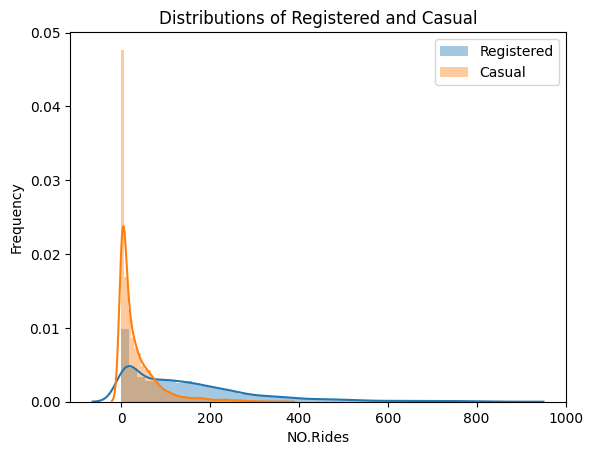

In [8]:
sns.distplot(preprocessed_data['registered'], label='Registered')
sns.distplot(preprocessed_data['casual'], label='Casual')
plt.legend()
plt.xlabel('NO.Rides')
plt.ylabel('Frequency')
plt.title('Distributions of Registered and Casual')
plt.savefig('Figures/Distributions of Registered and Casual.png', format='png')

- Showing the Regisered and Casual rides over time.

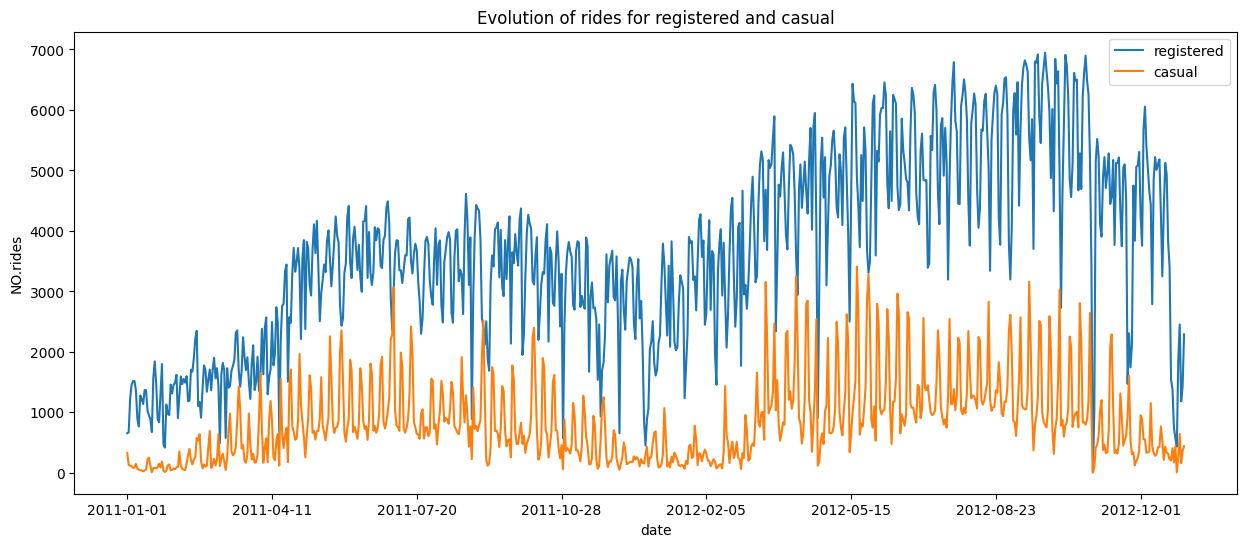

In [9]:
cols = ['dteday', 'registered', 'casual']
data_plot = preprocessed_data[cols].groupby('dteday').sum().plot(figsize=(15,  6))

plt.xlabel('date')
plt.ylabel('NO.rides')
plt.title('Evolution of rides for registered and casual')
plt.savefig('Figures/Evolution of rides.png', format='png')

- You saw the evolution of the rides but the plot is a lot noisy and hard to read  so is there any other way to make is smooth ?

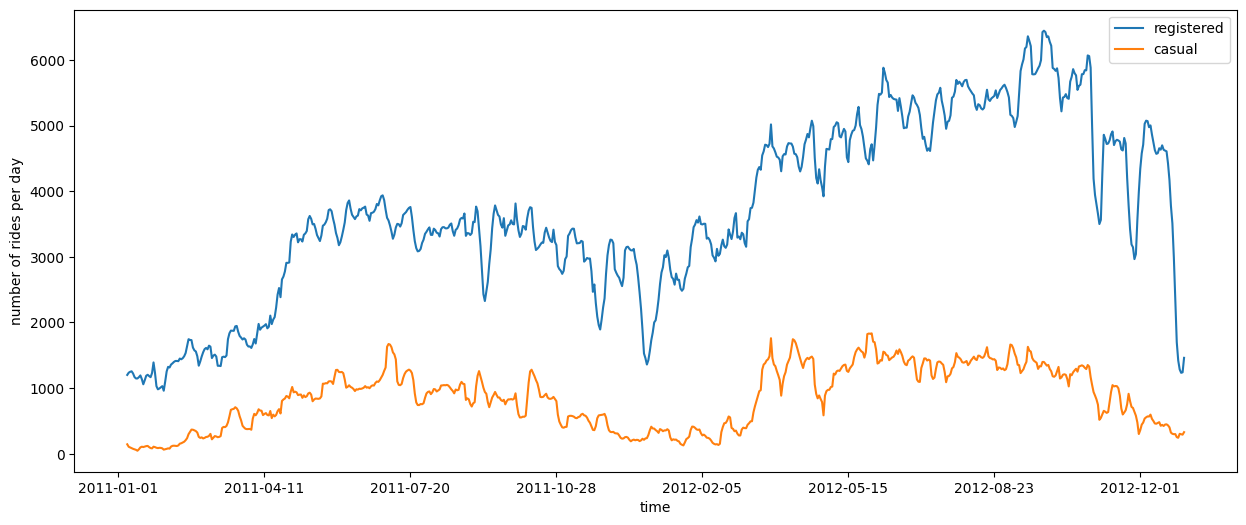

In [10]:
# Using the rolling mean and standard with window of seven (No. days) deviation to smooth the plot

data_plot = preprocessed_data[cols].groupby('dteday').sum()

rolling_means = data_plot.rolling(7).mean()

ax = rolling_means.plot(figsize=(15, 6))

ax.set_xlabel("time")
ax.set_ylabel("number of rides per day");
plt.savefig('Figures/rides_over_days.png', format='png')

- Now it's time to show which cases gives higher rides.
-- wheather related features--

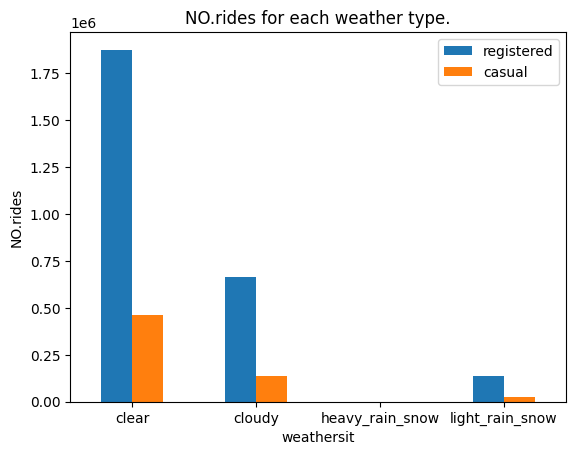

In [11]:
data = preprocessed_data[['weathersit', 'registered', 'casual']]
plot_data = data.groupby('weathersit').sum()
plot_data.plot(kind='bar', rot=0)
plt.ylabel('NO.rides')
plt.title('NO.rides for each weather type.')
plt.savefig('Figures/NO.rides for each type of weather.png', format='png')

- Analysis on the seasons

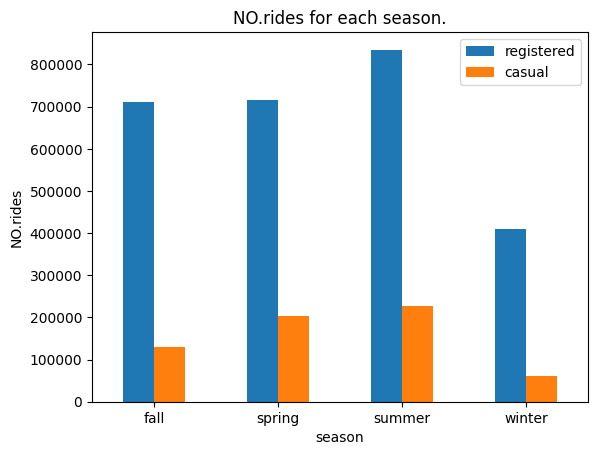

In [12]:
data = preprocessed_data[['season', 'registered', 'casual']]
plot_data = data.groupby('season').sum()
plot_data.plot(kind='bar', rot=0)
plt.ylabel('NO.rides')
plt.title('NO.rides for each season.')
plt.savefig('Figures/NO.rides for each season.png', format='png')

- now it's time to see how our business is doing on each day depending on the hours of the day

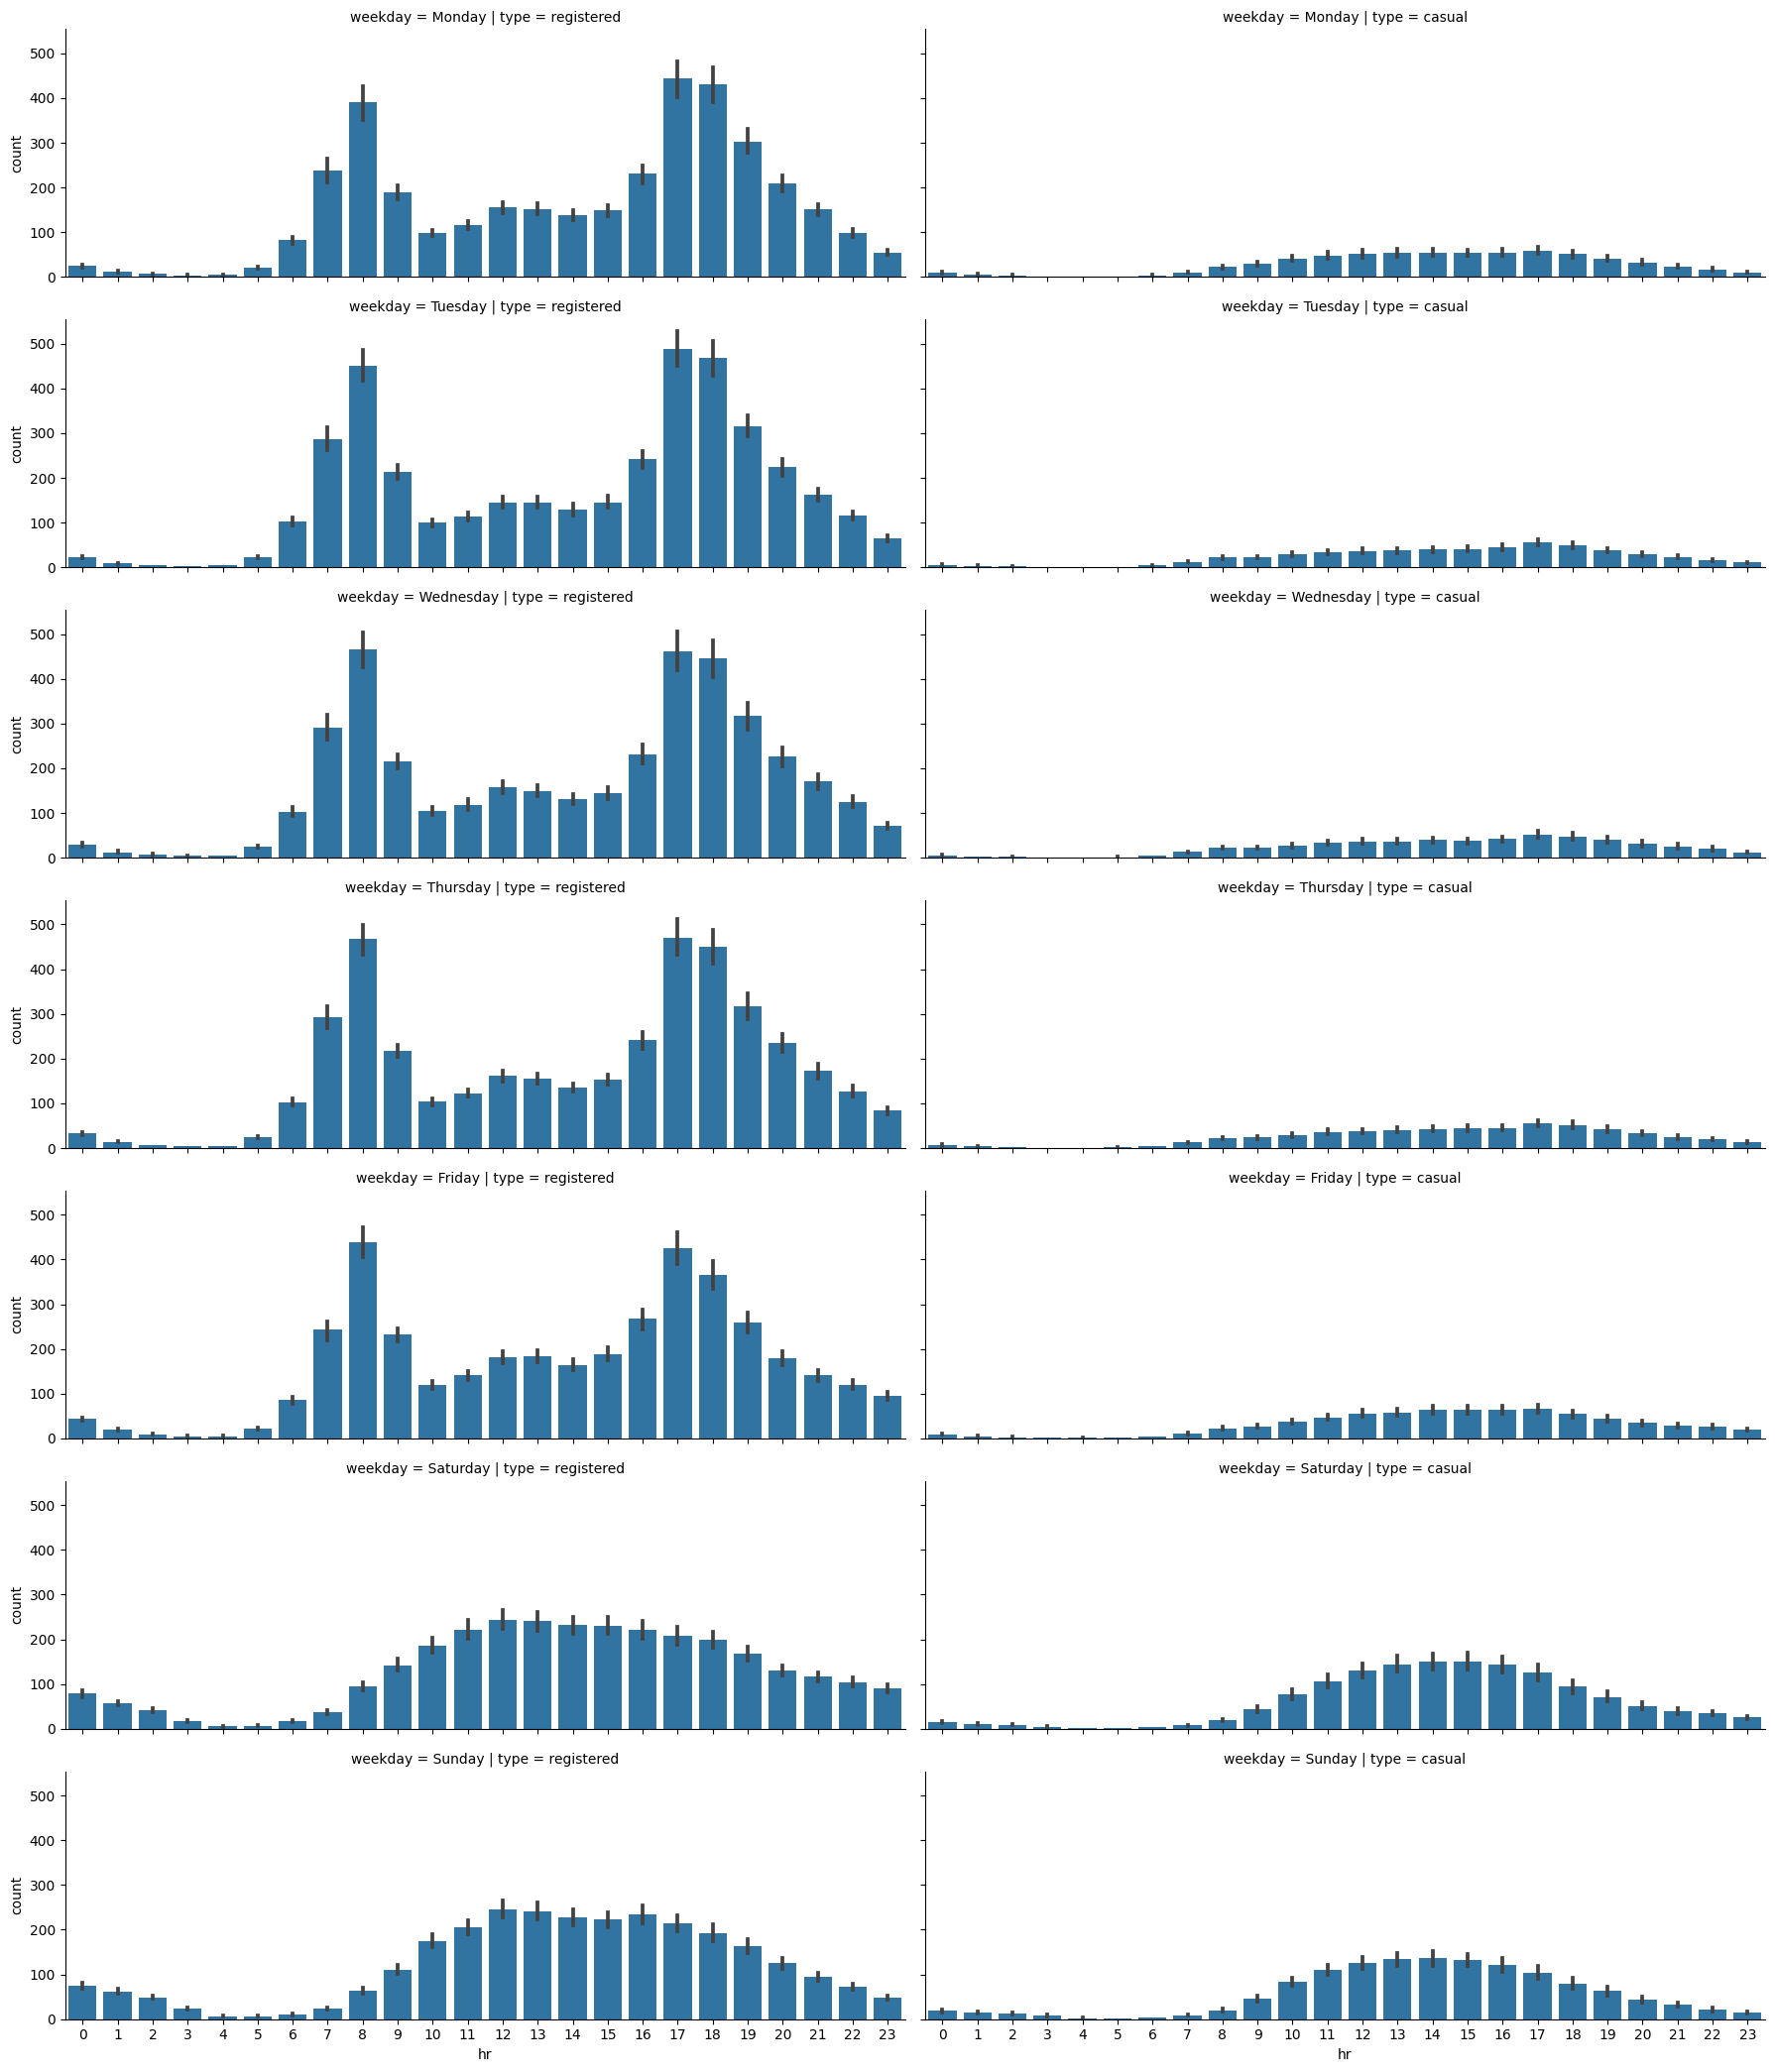

In [13]:
cols = ['hr', 'weekday', 'registered', 'casual']  # Select the needed columns
data = preprocessed_data[cols].melt(id_vars=['weekday', 'hr'], var_name='type', value_name='count')  # Create unpivot table to plot

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']  # the order of the days
ax = sns.FacetGrid(data=data, row='weekday', col='type', row_order=order, height=3, aspect=3)  # face grid for the plots
ax.map(sns.barplot, 'hr', 'count')  # apply the barplot  as  our plot

plt.savefig('Figures/Rides in each day represented by hours.png', format='png')

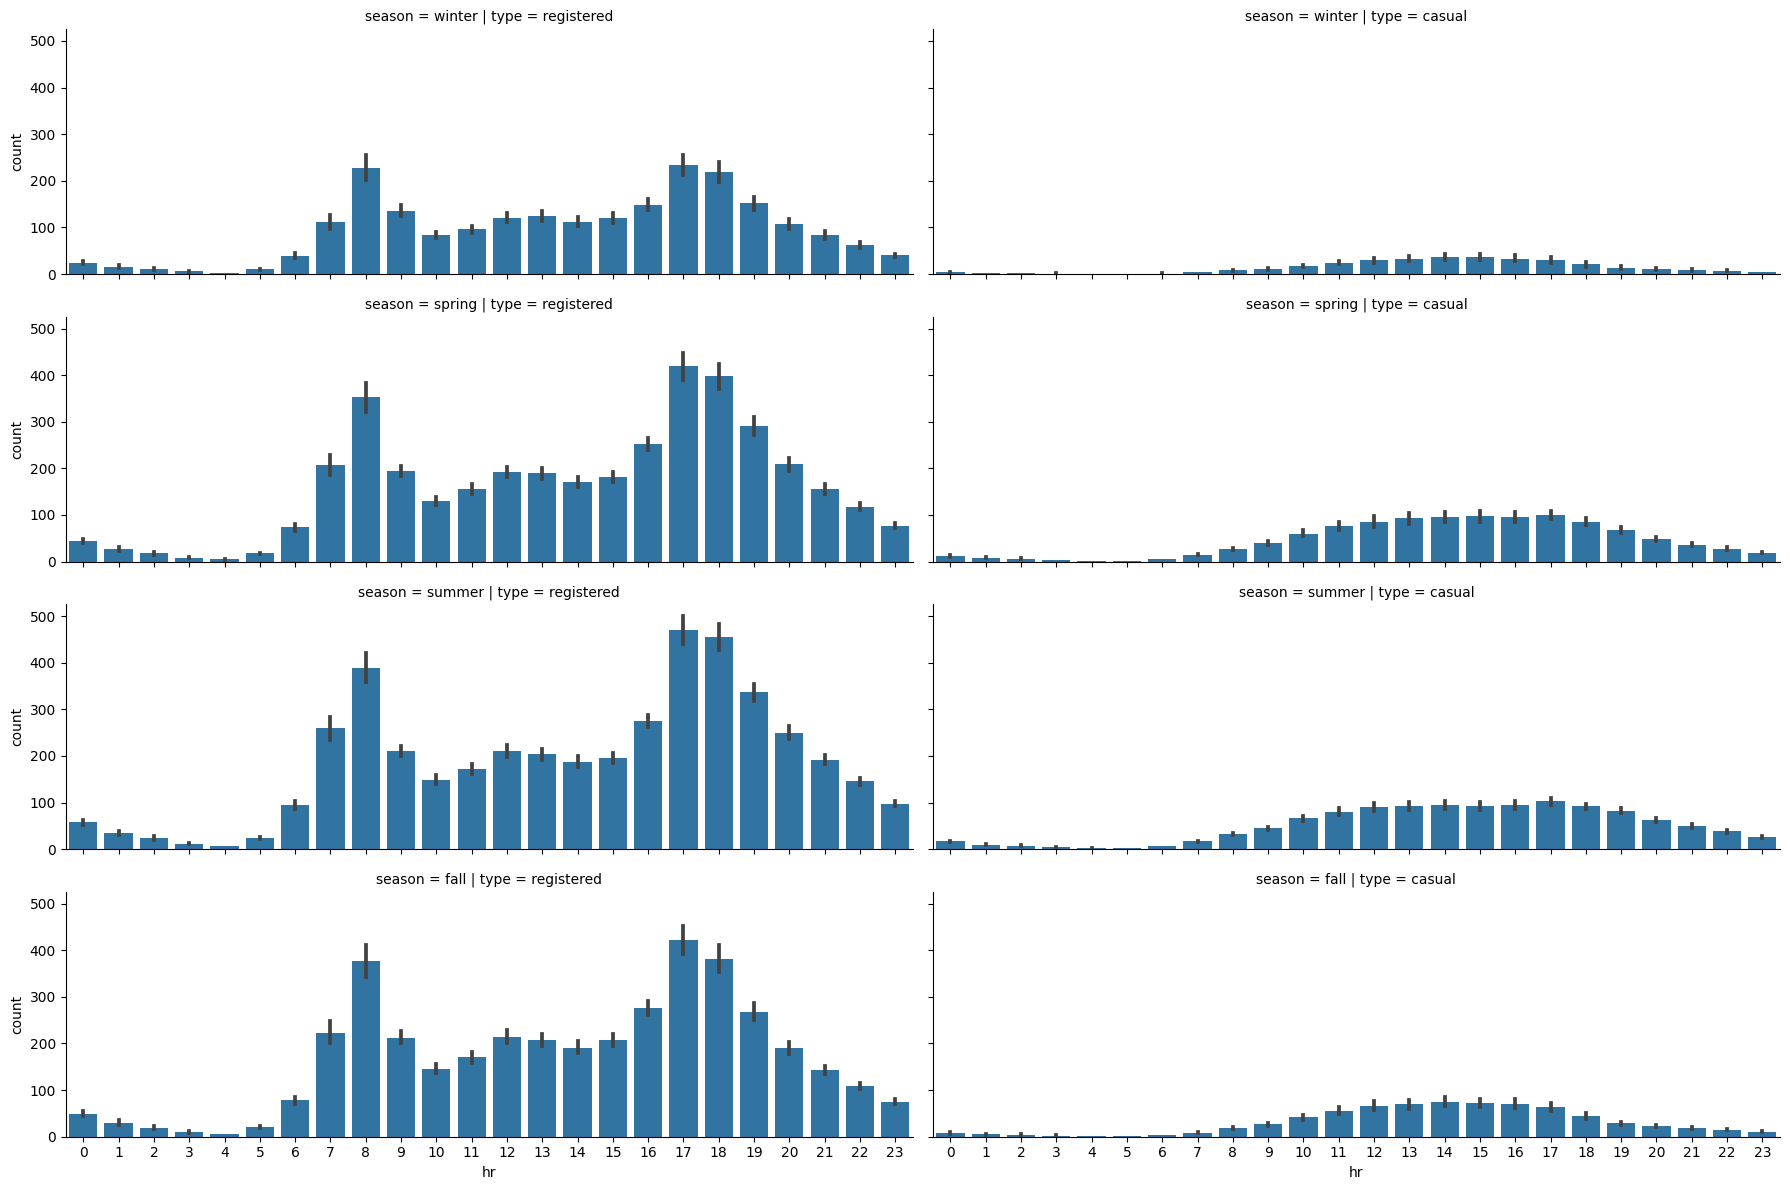

In [14]:
cols = ['hr', 'season', 'registered', 'casual']  # Select the needed columns
data = preprocessed_data[cols].melt(id_vars=['hr', 'season'], var_name='type', value_name='count')  # Create unpivot table to plot

order = ['winter', 'spring', 'summer', 'fall']  # the order of the Seasons
ax = sns.FacetGrid(data=data, row='season', col='type', row_order=order, height=3, aspect=3)  # face grid for the plots
ax.map(sns.barplot, 'hr', 'count')  # apply the barplot  as  our plot

plt.savefig('Figures/Rides for each by hours of the day.png', format='png')

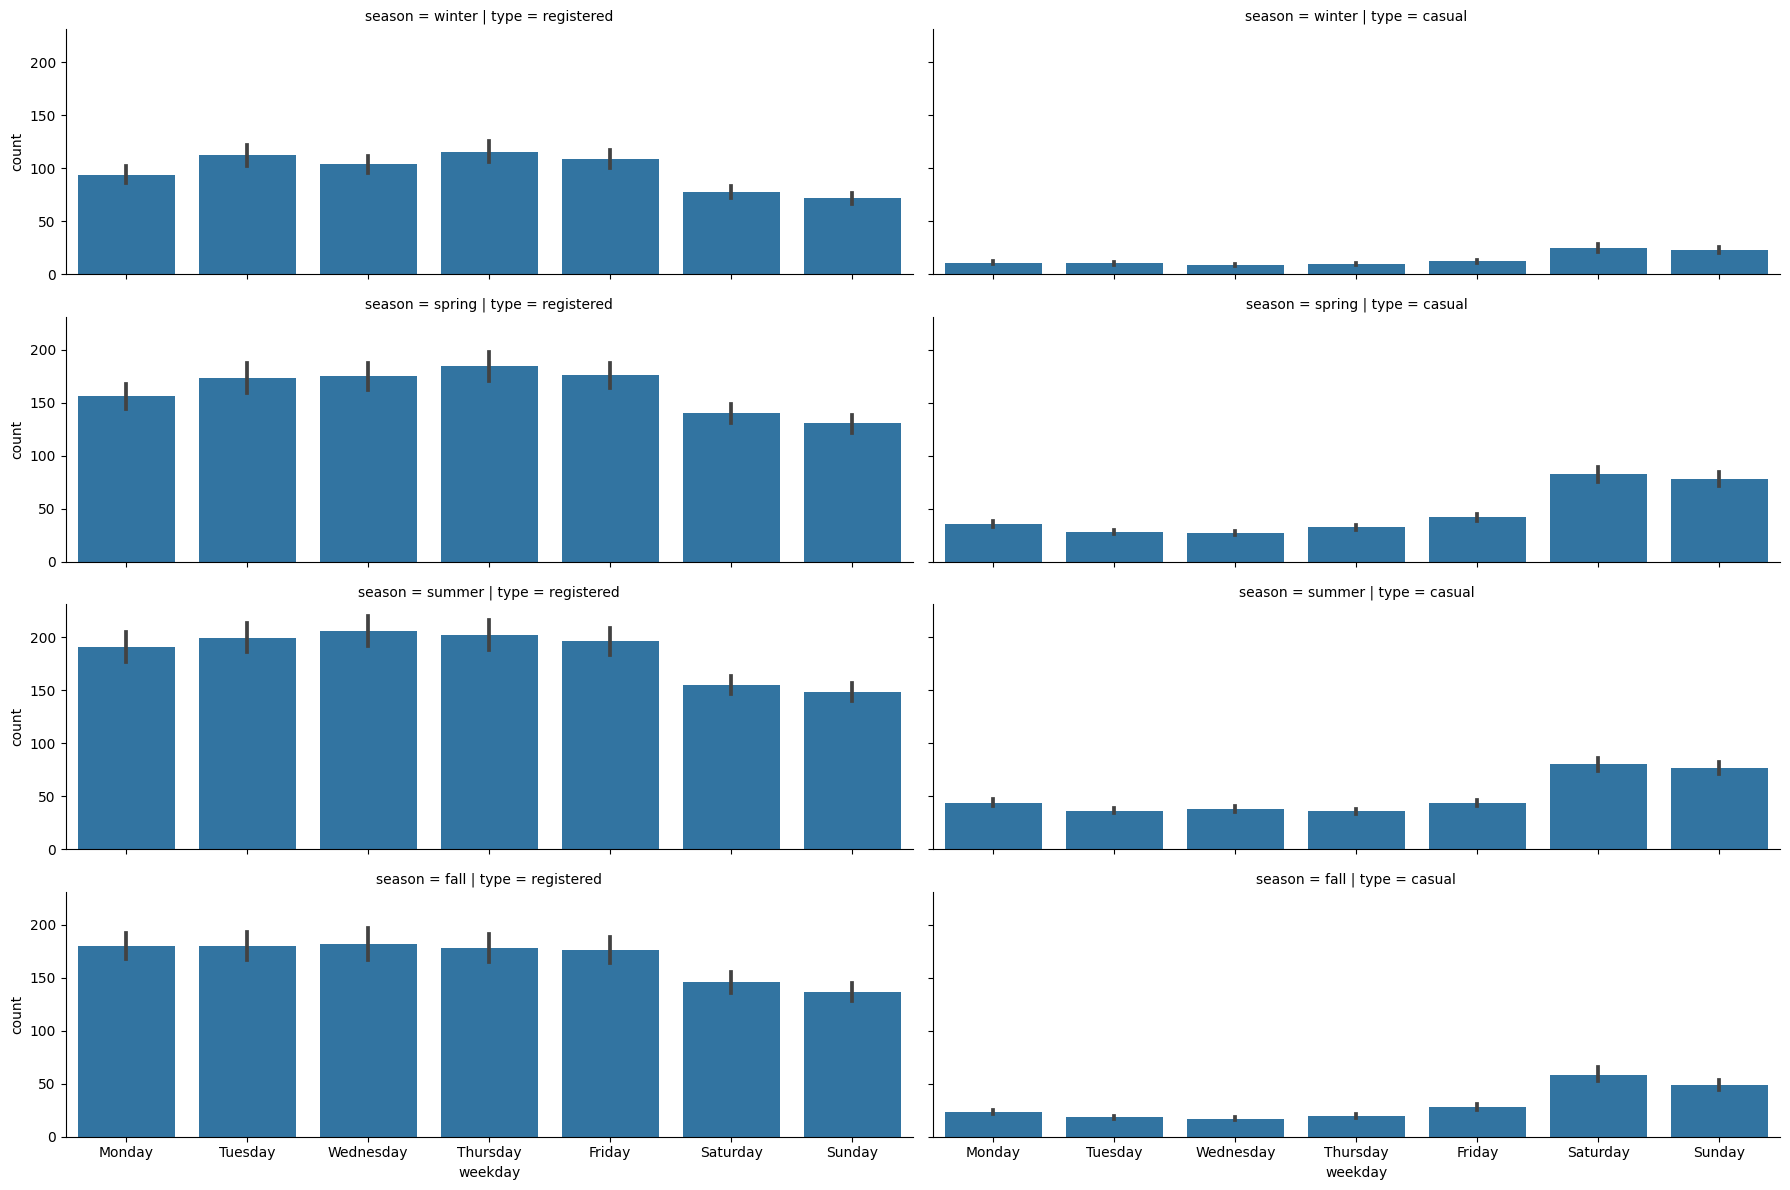

In [15]:
cols = ['weekday', 'season', 'registered', 'casual']  # Select the needed columns
data = preprocessed_data[cols].melt(id_vars=['weekday', 'season'], var_name='type', value_name='count')  # Create unpivot table to plot

order = ['winter', 'spring', 'summer', 'fall']  # the order of the Seasons
ax = sns.FacetGrid(data=data, row='season', col='type', row_order=order, height=3, aspect=3)  # face grid for the plots

plot_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ax.map(sns.barplot, 'weekday', 'count', order=plot_order)  # apply the barplot  as  our plot

plt.savefig('Figures/Rides of each season represented by days.png', format='png')

#### Now It's time for hypothesis testing.
1. Registered rides are more than Casual rides.  (fail to reject the null hypothesis)
2. Clear weather tend to have more rides than any other weather type.  (fail to reject the null hypothesis)
3. Summer season tend to have more rides than any other season.  (fail to reject the null hypothesis)
4. Working days tend to have more registered rides than Weekend days.  (fail to reject the null hypothesis)
5. Weekend days tend to have more Casaual Rides than Working Days.  (fail to reject the null hypothesis)
6. There is a huge Rigestered peek at hours(7, 8, 9)A.M and (4, 5, 6, 7)P.M (reject the null hypothesis)
7. Winter tend to have the lowest N.O rides between all seasons.  (fail to reject the null hypothesis)
8. heavy_rain_snow tend to have the lowest N.O rides between all the weather types.  (reject the null hypothesis)

- Registered rides are more than Casual rides.

In [16]:
# Define registered and casual rides per day.
registered = preprocessed_data.groupby('dteday')['registered'].sum()
casual = preprocessed_data.groupby('dteday')['casual'].sum()

statistic, p_value = stats.ttest_ind(registered, casual, alternative='less')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : 44.537, p-value: 1.000


- Clear weather tend to have more rides than any other weather type.

In [17]:
condition = preprocessed_data['weathersit'].isin(['clear'])

other_weather_types = preprocessed_data[~condition].cnt
clear = preprocessed_data[condition].cnt.sample(n=other_weather_types.shape[0])

statistic, p_value = stats.ttest_ind(clear, other_weather_types, alternative='less')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : 13.491, p-value: 1.000


- Summer season tend to have more rides than any other season.

In [18]:
condition = preprocessed_data['season'] == 'summer'
summer = preprocessed_data[condition].cnt
other_seasons = preprocessed_data[~condition].cnt.sample(n=summer.shape[0])

statistic, p_value = stats.ttest_ind(clear, other_seasons, alternative='less')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : 8.834, p-value: 1.000


- Working days tend to have more registered rides than Weekend days.


In [19]:
working_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
condition = preprocessed_data['weekday'].isin(working_days)

weekend_days_data = preprocessed_data[~condition].registered
working_days_data = preprocessed_data[condition].registered.sample(n=weekend_days_data.shape[0])

statistic, p_value = stats.ttest_ind(working_days_data, weekend_days_data, alternative='less')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : 13.687, p-value: 1.000


- Weekend days tend to have more Casaual Rides than Working Days.

In [20]:
weekend_days = ['Saturday', 'Sunday']
condition = preprocessed_data['weekday'].isin(weekend_days)
weekend_days_data = preprocessed_data[condition].casual
working_days_data = preprocessed_data[~condition].casual.sample(n=weekend_days_data.shape[0])

statistic, p_value = stats.ttest_ind(weekend_days_data, working_days_data, alternative='less')


print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : 29.421, p-value: 1.000


- Winter tend to have the lowest N.O rides between all seasons.


In [21]:
condition = preprocessed_data['season'] == 'winter'
winter_rides = preprocessed_data[condition].cnt
other_seasons_rides = preprocessed_data[~condition].cnt.sample(n=winter_rides.shape[0])

statistic, p_value = stats.ttest_ind(winter_rides, other_seasons_rides, alternative='greater')


print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : -30.394, p-value: 1.000



- heavy_rain_snow tend to have the lowest N.O rides between all the weather types.

In [22]:
condition = preprocessed_data['weathersit'] == 'heavy_rain_snow'
heavy_rain_snow = preprocessed_data[condition].cnt
other_weather_types = preprocessed_data[~condition].cnt.sample(n=heavy_rain_snow.shape[0])

statistic, p_value = stats.ttest_ind(heavy_rain_snow, other_weather_types, alternative='greater')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : -2.566, p-value: 0.969


- There is a huge N.O Registered rides Peek at  hours (7, 8, 9)AM and (4, 5, 6, 7)PM in the working days

In [23]:
peek_hours = [8, 17, 18]
data = preprocessed_data[ preprocessed_data.weekday.isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']) ]

condition = data['hr'].isin(peek_hours)
peek_hours_rides = data[condition].registered
other_hours_rides = data[~condition].registered.sample(n=peek_hours_rides.shape[0])

statistic, p_value = stats.ttest_ind(peek_hours, other_hours_rides, alternative='less')

print(f'statistic is : {statistic:.003f}, p-value: {p_value:.003f}')

statistic is : -1.678, p-value: 0.047


- Analysis on Weather related features.
'The Function comes from the book'

In [24]:
def plot_correlations(data, col):
    # get correlation between col and registered rides
    corr_r = np.corrcoef(data[col], data["registered"])[0,1]
    ax = sns.regplot(x=col, y="registered", data=data, scatter_kws={"alpha":0.05}, 
                     label=f"Registered rides (correlation: {corr_r:.3f})")
    
    # get correlation between col and casual rides
    corr_c = np.corrcoef(data[col], data["casual"])[0,1]
    ax = sns.regplot(x=col, y='casual', data=data, scatter_kws={"alpha":0.05}, 
                    label=f"Casual rides (correlation: {corr_c:.3f})")
    
    #adjust legend alpha
    legend = ax.legend()
    for lh in legend.legendHandles: 
        lh.set_alpha(0.5)
        
    ax.set_ylabel("rides")
    ax.set_title(f"Correlation between rides and {col}")
    return ax

- See What is the correlation between Weather Features and (Registered and Casual)

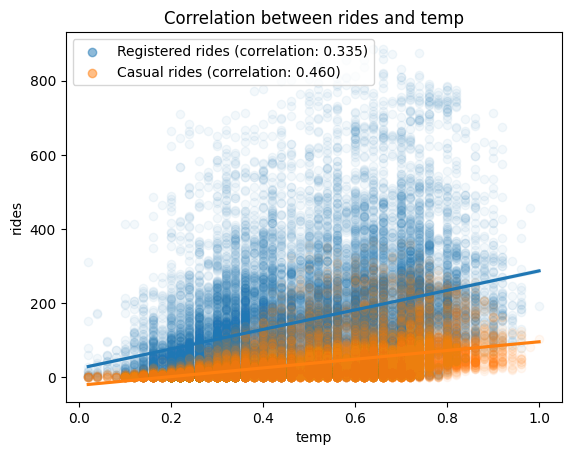

In [25]:
plot_correlations(preprocessed_data, 'temp')
plt.savefig('Figures/CORR_temp_REG_CAS', format='png')

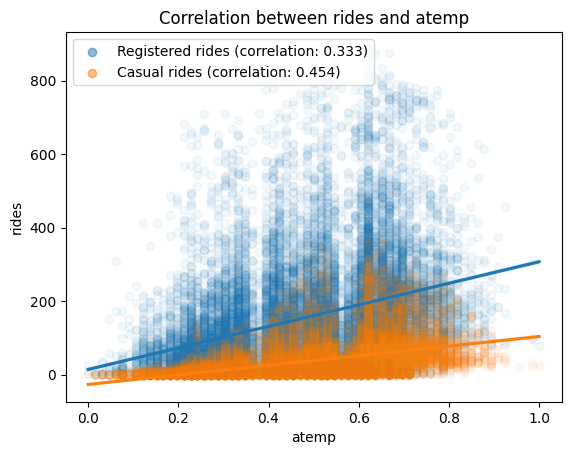

In [26]:
plot_correlations(preprocessed_data, 'atemp')
plt.savefig('Figures/CORR_atemp_REG_CAS', format='png')

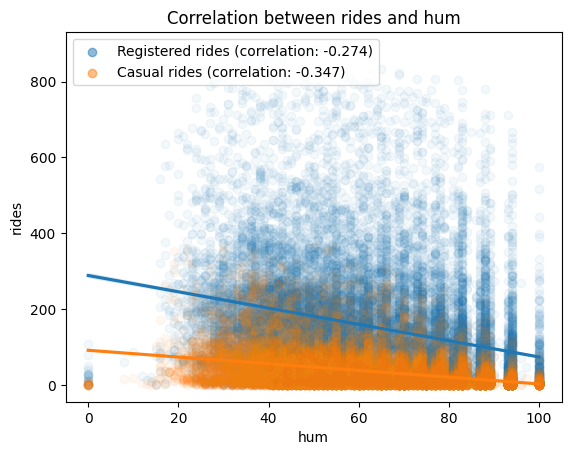

In [27]:
plot_correlations(preprocessed_data, 'hum')
plt.savefig('Figures/CORR_hum_REG_CAS', format='png')

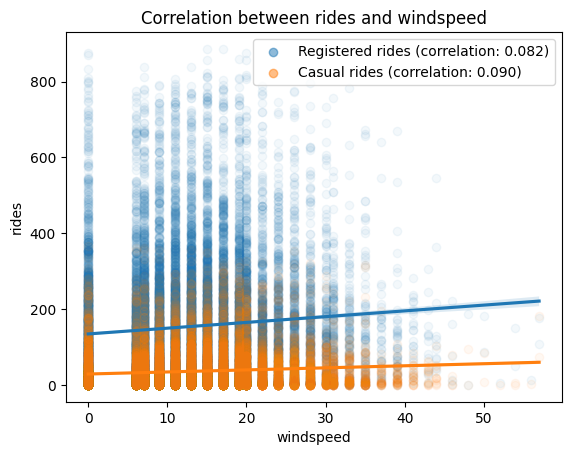

In [28]:
plot_correlations(preprocessed_data, 'windspeed')
plt.savefig('Figures/CORR_windspeed_REG_CAS', format='png')

                temp     atemp       hum  windspeed  registered    casual
temp        1.000000  0.987672 -0.069881  -0.023125    0.335361  0.459616
atemp       0.987672  1.000000 -0.051918  -0.062336    0.332559  0.454080
hum        -0.069881 -0.051918  1.000000  -0.290105   -0.273933 -0.347028
windspeed  -0.023125 -0.062336 -0.290105   1.000000    0.082321  0.090287
registered  0.335361  0.332559 -0.273933   0.082321    1.000000  0.506618
casual      0.459616  0.454080 -0.347028   0.090287    0.506618  1.000000


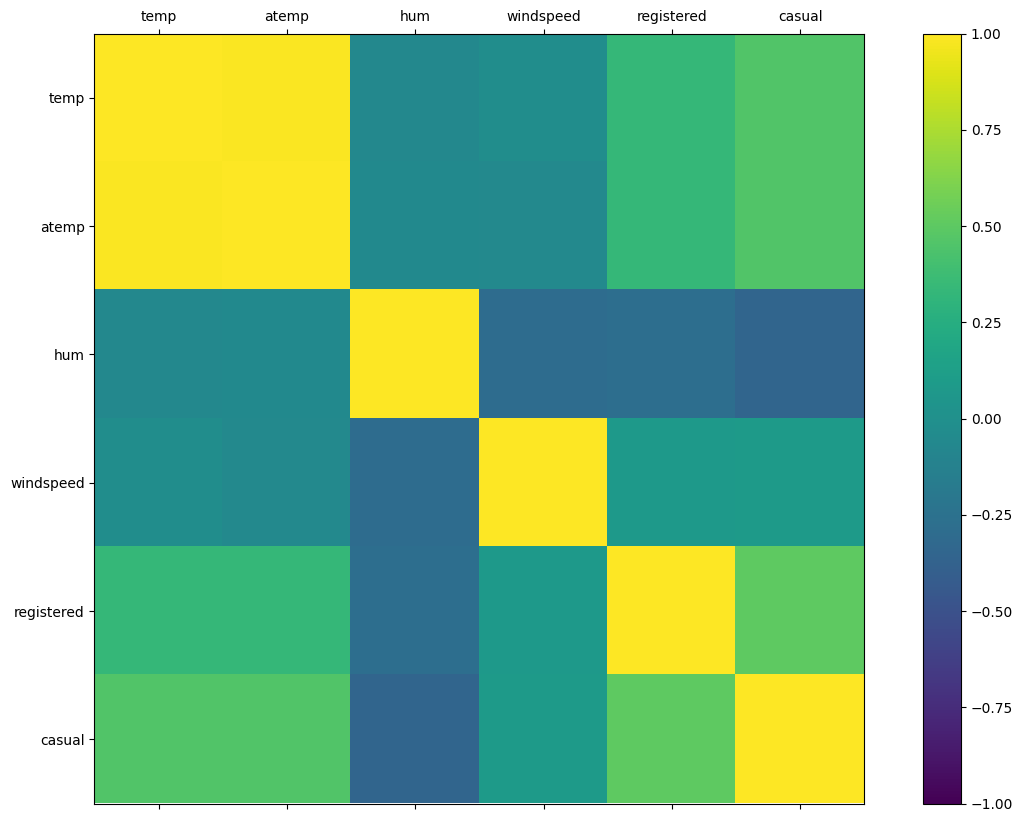

In [29]:
cols = ['temp', 'atemp', 'hum', 'windspeed', 'registered', 'casual']
data = preprocessed_data[cols]

correlations = data.corr()

print(correlations)

# plot correlation matrix
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0, data.shape[1])
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(data.columns)
ax.set_yticklabels(data.columns)

plt.savefig('Figures/Correlations.png',format='png')

In [30]:
from  scipy.stats import pearsonr, spearmanr

def wheather_on_reg_and_cas(data, col_name, weather_cond):
    plot_data = data[data['weathersit'] == weather_cond]

    # compute pearson correlation between col_name and registered rides
    pearson_corr_r = spearmanr(plot_data[col_name], plot_data["registered"])
    
    # compute pearson correlation between col_name and registered rides
    pearson_corr_c = spearmanr(plot_data[col_name], plot_data["casual"])

    ax = sns.regplot(data=plot_data, x=col_name, y='registered', scatter_kws={"alpha":0.05}, label='registered')
    ax = sns.regplot(data=plot_data, x=col_name, y='casual', scatter_kws={"alpha":0.05}, label='casual')

    plt.legend()
    ax.set_xlabel('')
    ax.set_ylabel('Number of Rides')
    ax.set_title(f'{col_name}, {weather_cond}, Corr:{pearson_corr_r[0]:3f}, P-val:{pearson_corr_c[1]:3f}')
    return ax

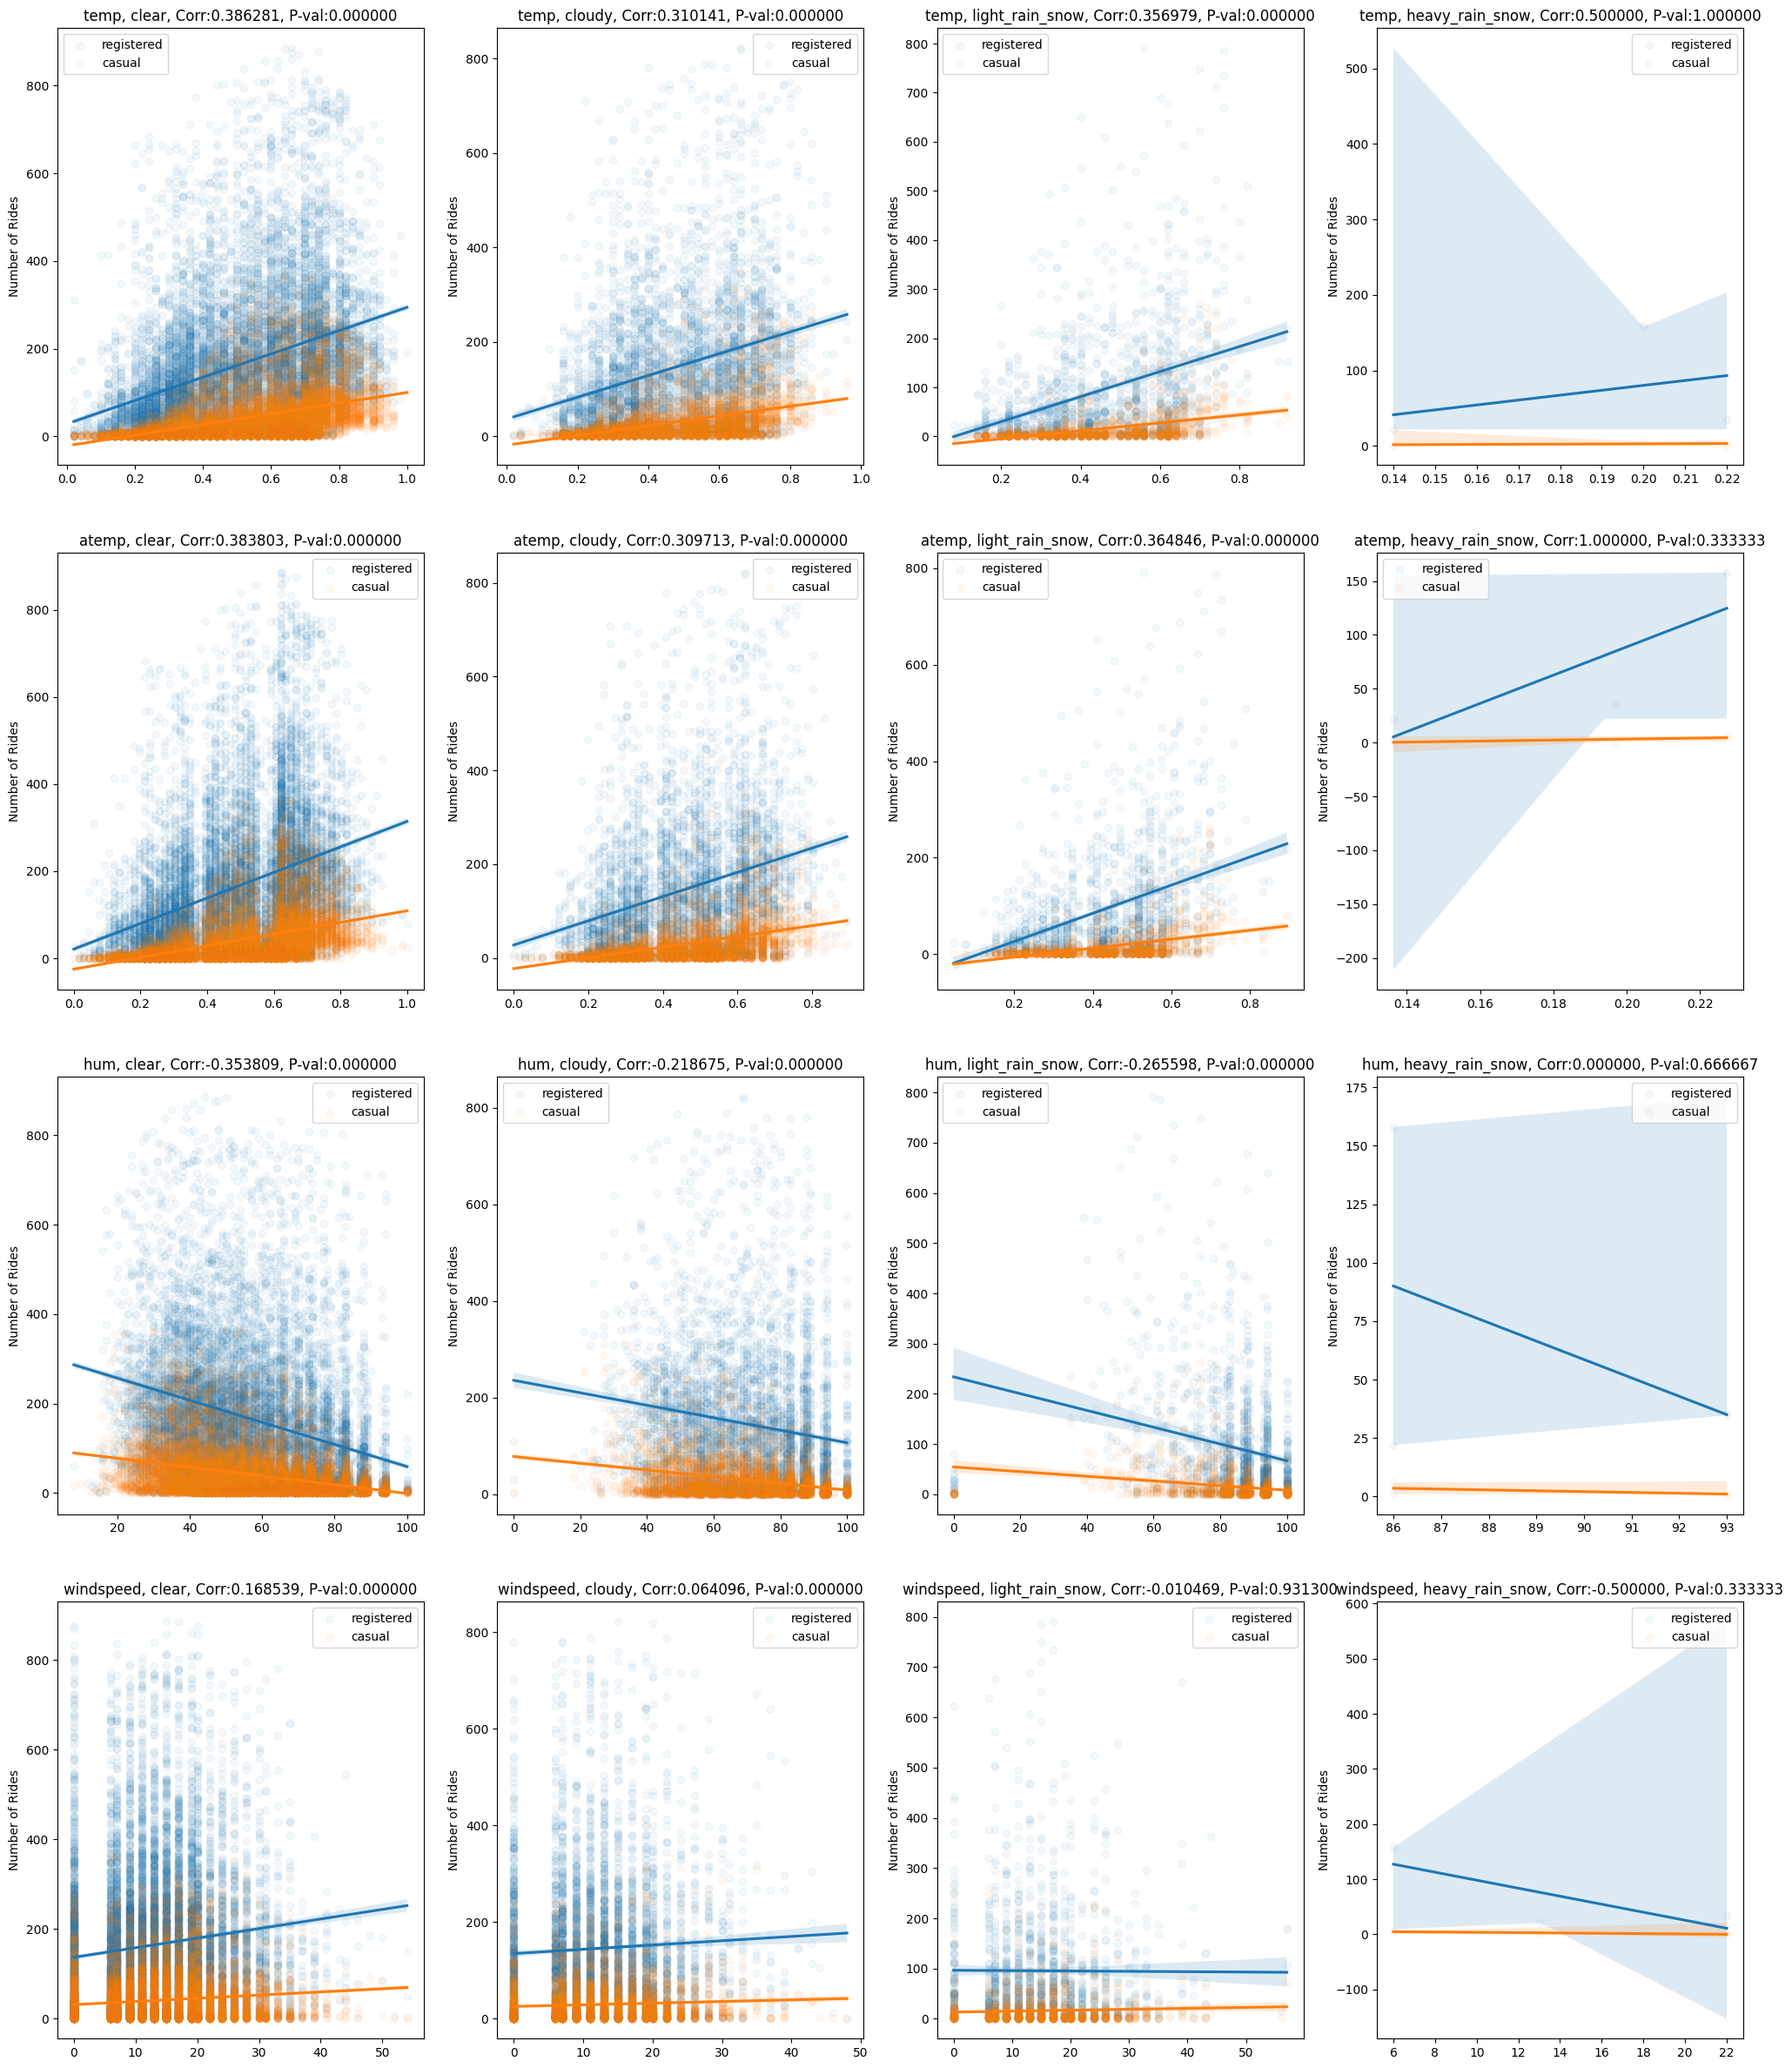

In [31]:
import scipy.stats as stats

weather_conditions = preprocessed_data.weathersit.unique()
temps = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(25,30))
for col_index, col in enumerate(temps):
    for row_index, weather_cond in enumerate(weather_conditions):
        plot_number = row_index + col_index * 4 + 1
        plt.subplot(4, 4, plot_number)
        wheather_on_reg_and_cas(preprocessed_data, col, weather_cond)
plt.savefig('FIgures/impact_of_weather_and_temp.png', format='png')

### Machine Learning Part

- Splitting Data into features and target

In [32]:
training_data = df.drop(['instant', 'dteday', 'registered', 'casual'], axis=1)
y = df['cnt']

- Models Comparison

GRB 0.9616408614584616 0.012265601255412952
ELSN 0.004328636587880533 6.0475912723913165e-05
ByR 6.6228022598487994e-12 2.354238766519171e-12
linr 1.1548359140147433e-13 4.042561806304451e-14
XGB 0.27855183510025805 0.008945614229098573
DecT 0.031590399947015915 0.005448663797789167
RNFR 0.024381295295178317 0.0018604033774568015


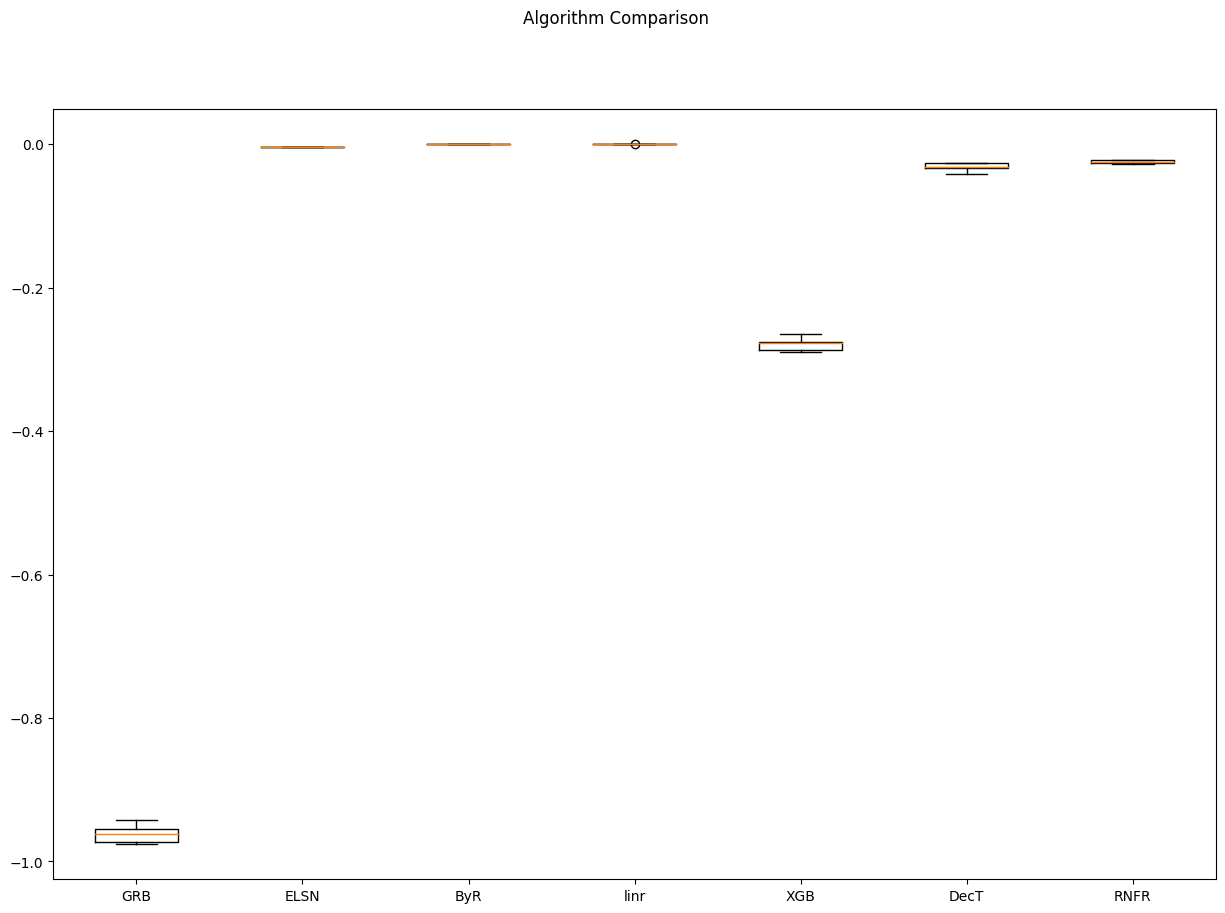

In [33]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import (BayesianRidge, ElasticNet, LinearRegression,
                                  SGDRegressor)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost.sklearn import XGBRegressor

models = [
    ('GRB', GradientBoostingRegressor()),
    # ('SVR', SVR()),
    ('ELSN', ElasticNet()),
	('ByR', BayesianRidge()),
    # ('KernR', KernelRidge()),
    ('linr', LinearRegression()),
    ('XGB', XGBRegressor()),
    ('DecT', DecisionTreeRegressor()),
    ('RNFR', RandomForestRegressor())
]
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=5, random_state=0, shuffle=True)
    cv_results = cross_val_score(model, training_data, y, cv=kfold, scoring = 'neg_mean_absolute_error')
    results.append(cv_results)
    names.append(name)
    print(name, -1 * cv_results.mean(), cv_results.std())
# boxplot algorithm comparison
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.savefig('Figures/Model_Comparison.png', format='png')
plt.show()

### Choose the best model and train it.
- We can see that the LinearRegression performed the best

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(training_data, y, test_size=0.3, random_state=0)

model = LinearRegression()

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(mean_absolute_error(y_test, pred))

7.92053206468301e-14


- Saving the model.

In [35]:
import pickle
# save the model to disk
filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))

- Loading the Model.

In [36]:
# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.score(X_test, y_test)
print(result)

1.0
